# Global Volcano Data Analysis

This project explores a global volcano dataset using Python and geospatial tools.

The objective is to analyze the spatial distribution of volcanoes and build a foundation for future remote sensing projects.

In [3]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

world.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


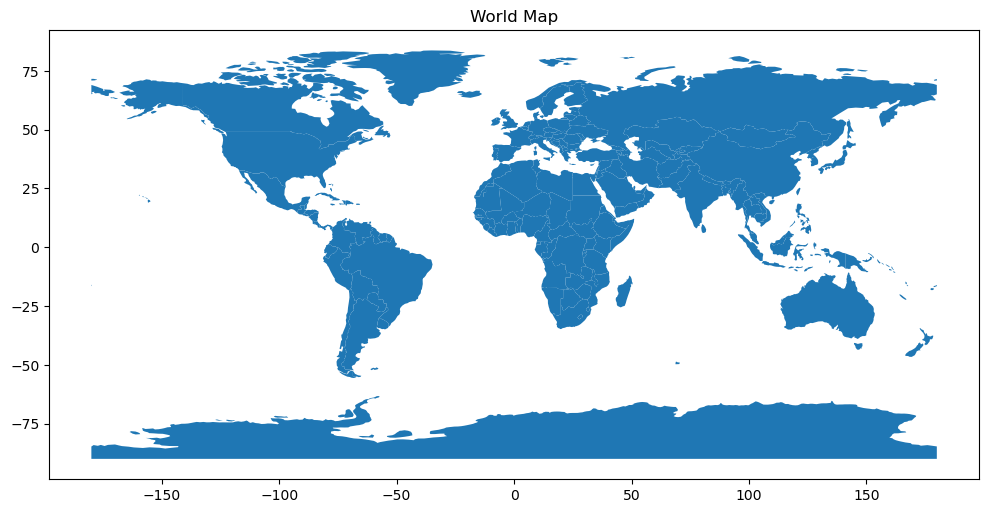

In [4]:
import matplotlib.pyplot as plt

world.plot(figsize=(12,7))
plt.title("World Map")
plt.show()

In [7]:
import pandas as pd
volcanoes = pd.read_csv("volcanoes.csv", encoding="latin1")
volcanoes.head()

,Number,Volcano Name,Country,Region,Latitude,Longitude,Elev,Type,Status,Last Known
0,0803-001,Abu,Japan,Honshu-Japan,34.500,131.600,571.0,Shield volcano,Holocene,Unknown
1,1505-096,Acamarachi,Chile,Chile-N,-23.300,-67.620,6046.0,Stratovolcano,Holocene,Unknown
2,1402-08=,Acatenango,Guatemala,Guatemala,14.501,-90.876,3976.0,Stratovolcano,Historical,D1
3,0103-004,Acigol-Nevsehir,Turkey,Turkey,38.570,34.520,1689.0,Maar,Holocene,U
4,1201-04-,Adams,United States,US-Washington,46.206,-121.490,3742.0,Stratovolcano,Tephrochronology,D6


## Dataset Overview

The volcano dataset contains information about volcano locations,
types, and activity status around the world.

The dataset includes geographic coordinates that allow geospatial
visualization and analysis.

In [16]:
volcanoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Number        1571 non-null   str    
 1   Volcano Name  1571 non-null   str    
 2   Country       1571 non-null   str    
 3   Region        1571 non-null   str    
 4   Latitude      1571 non-null   float64
 5   Longitude     1571 non-null   float64
 6   Elev          1558 non-null   float64
 7   Type          1571 non-null   str    
 8   Status        1571 non-null   str    
 9   Last Known    1571 non-null   str    
dtypes: float64(3), str(7)
memory usage: 122.9 KB


In [17]:
volcanoes.describe()

,Latitude,Longitude,Elev
count,1571.000000,1571.000000,1558.000000
mean,14.675608,23.437350,1627.110398
std,31.923949,112.851068,1623.457706
min,-78.500000,-179.970000,-6000.000000
25%,-6.725000,-78.063500,639.250000
50%,14.070000,38.120000,1448.500000
75%,42.390000,137.525000,2334.750000
max,88.270000,179.620000,6887.000000


In [8]:
volcanoes.shape

(1571, 10)

In [9]:
volcanoes.columns

Index(['Number', 'Volcano Name', 'Country', 'Region', 'Latitude', 'Longitude',
       'Elev', 'Type', 'Status', 'Last Known'],
      dtype='str')

In [10]:
import geopandas as gpd

volcanoes = volcanoes.dropna(subset=["Latitude", "Longitude"])

volcanoes_gdf = gpd.GeoDataFrame(
    volcanoes,
    geometry=gpd.points_from_xy(volcanoes["Longitude"], volcanoes["Latitude"]),
    crs="EPSG:4326"
)

volcanoes_gdf.head()

,Number,Volcano Name,Country,Region,Latitude,Longitude,Elev,Type,Status,Last Known,geometry
0,0803-001,Abu,Japan,Honshu-Japan,34.500,131.600,571.0,Shield volcano,Holocene,Unknown,POINT (131.6 34.5)
1,1505-096,Acamarachi,Chile,Chile-N,-23.300,-67.620,6046.0,Stratovolcano,Holocene,Unknown,POINT (-67.62 -23.3)
2,1402-08=,Acatenango,Guatemala,Guatemala,14.501,-90.876,3976.0,Stratovolcano,Historical,D1,POINT (-90.876 14.501)
3,0103-004,Acigol-Nevsehir,Turkey,Turkey,38.570,34.520,1689.0,Maar,Holocene,U,POINT (34.52 38.57)
4,1201-04-,Adams,United States,US-Washington,46.206,-121.490,3742.0,Stratovolcano,Tephrochronology,D6,POINT (-121.49 46.206)


## Geospatial Visualization

The volcano dataset was converted into a GeoDataFrame using latitude and longitude coordinates.

Then, volcano locations were plotted on a world map to visualize their global spatial distribution.

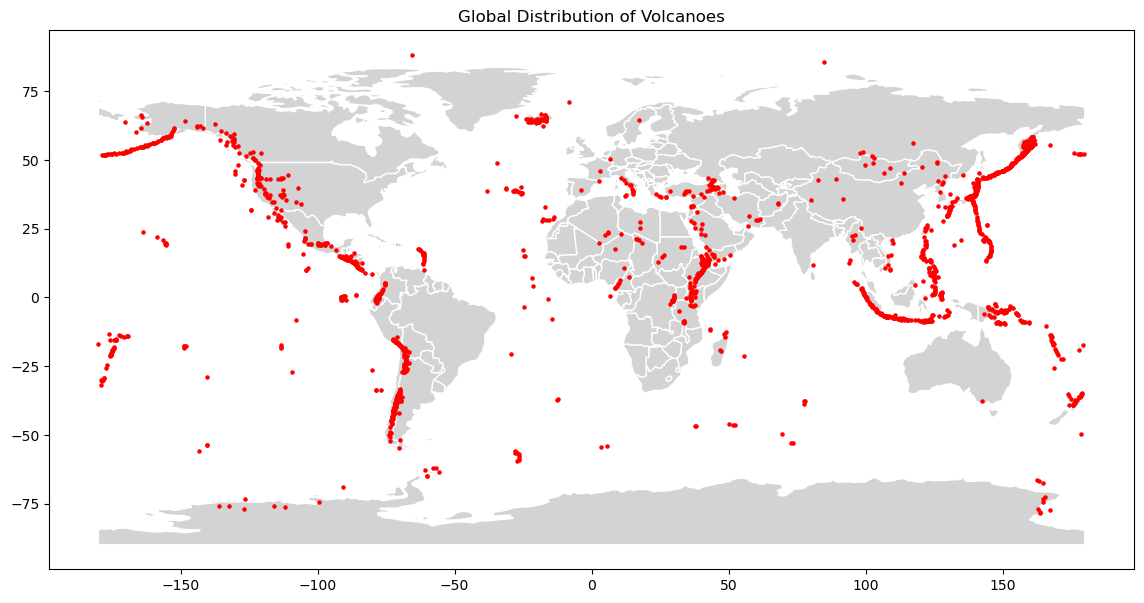

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))

world.plot(ax=ax, color="lightgray", edgecolor="white")
volcanoes_gdf.plot(ax=ax, color="red", markersize=5)

plt.title("Global Distribution of Volcanoes")
plt.show()

## Exploratory Analysis

This section identifies the countries with the highest number of volcanoes and the most common volcano types in the dataset.

In [12]:
top_countries = volcanoes["Country"].value_counts().head(10)
top_countries

Country
United States       184
Russia              169
Indonesia           136
Japan               111
Chile                87
Ethiopia             57
Papua New Guinea     54
Philippines          49
Mexico               41
Iceland              38
Name: count, dtype: int64

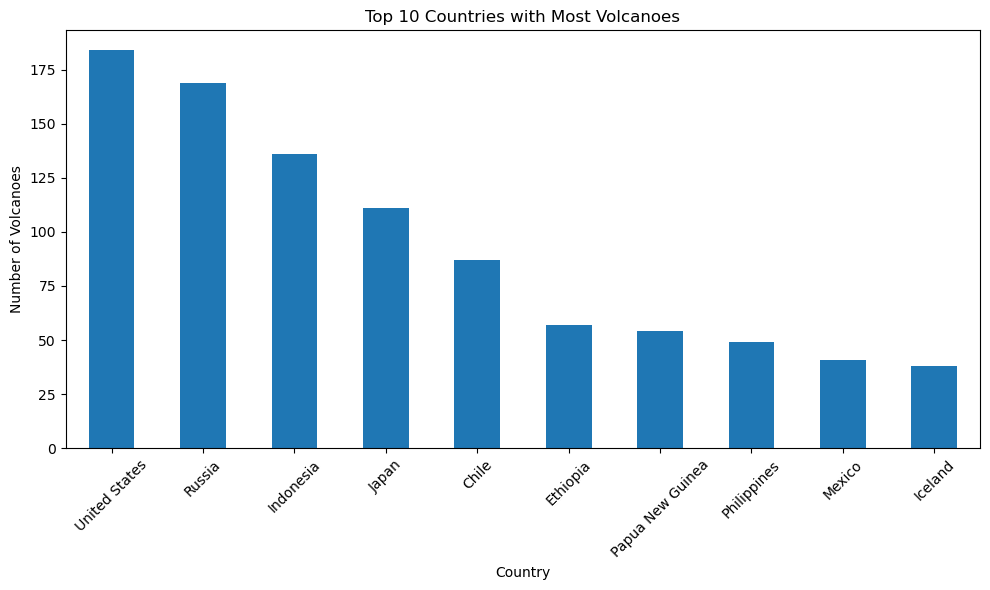

In [18]:
top_countries.plot(kind="bar", figsize=(10,6))
plt.title("Top 10 Countries with Most Volcanoes")
plt.xlabel("Country")
plt.ylabel("Number of Volcanoes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
top_types = volcanoes["Type"].value_counts().head(10)
top_types

Type
Stratovolcano        704
Shield volcano       169
Submarine volcano    142
Volcanic field        95
Caldera               84
Cinder cone           76
Complex volcano       53
Lava dome             37
Pyroclastic cone      36
Maar                  19
Name: count, dtype: int64

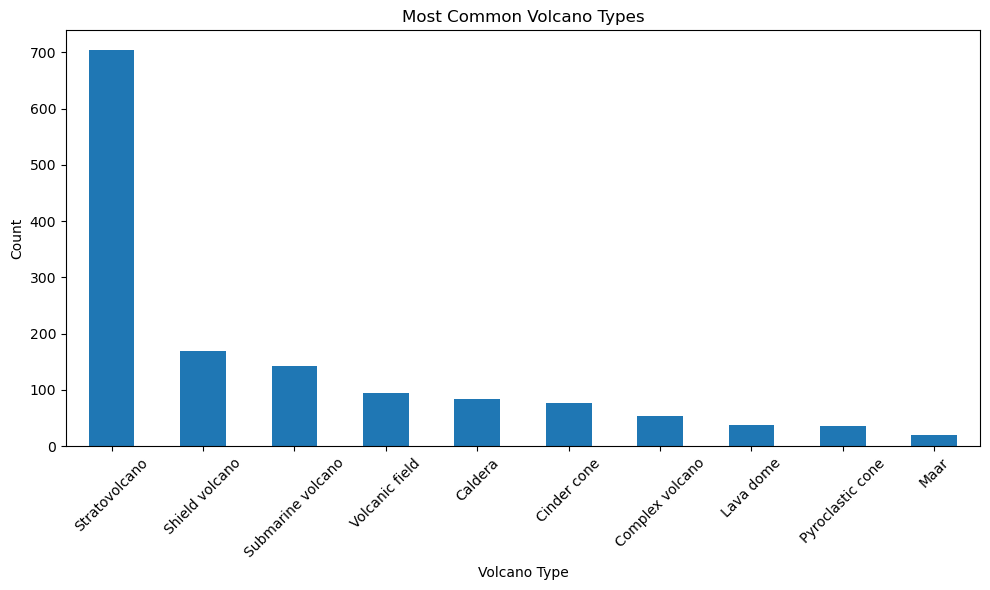

In [14]:
top_types.plot(kind="bar", figsize=(10, 6))
plt.title("Most Common Volcano Types")
plt.xlabel("Volcano Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusions

This exploratory analysis shows the global distribution of volcanoes and
identifies the countries with the highest number of volcanoes.

The dataset also reveals the most common volcano types worldwide.

This project serves as a foundation for future geospatial and remote
sensing analysis of volcanic activity.